# StormScope over Wyoming
## Coupled GOES satellite + MRMS radar nowcasting with Earth2Studio

This notebook runs the current Earth2Studio StormScope **3 km / 10 minute CONUS** workflow and focuses the analysis on Wyoming. It forecasts:

- eight GOES ABI satellite channels with `StormScopeGOES`;
- MRMS composite reflectivity, base reflectivity, and gridded GLM lightning density with `StormScopeMRMS`;
- a sequence of probabilistic, autoregressive 10-minute nowcasts.

The example case initializes at **2023-06-23 23:00 UTC (5:00 PM MDT)**, just before a cyclic supercell produced a family of tornadoes from Chugwater and Hawk Springs, Wyoming, toward Scottsbluff, Nebraska. The first documented Chugwater tornado began at 5:11 PM MDT. See the [NWS Cheyenne event summary](https://www.weather.gov/cys/June23ChugwatertoScottsblufftornados).

> **Important:** StormScope forecasts satellite, radar, and lightning-like fields. It does **not** directly predict tornadoes, hail, warnings, or impacts. This notebook is for research and education—not operational warning decisions.

### Learning objectives

By the end, you will be able to:

1. explain the coupled GOES → MRMS StormScope architecture;
2. fetch the observation history required at initialization;
3. respect Earth2Studio's tensor/coordinate contract;
4. run a 10-minute autoregressive nowcast;
5. isolate Wyoming only at the analysis/plotting stage;
6. make a reflectivity/lightning dashboard and simple threshold diagnostics;
7. optionally compare the nowcast with later MRMS observations;
8. save the Wyoming subset to a reusable Zarr store.

## 1. What StormScope is doing

StormScope is a diffusion-transformer nowcasting model with 2-D neighborhood attention. The current recommended Earth2Studio checkpoint is `3km_10min`:

- **grid:** HRRR's CONUS Lambert conformal grid at about 3 km;
- **time step:** 10 minutes;
- **GOES state:** `abi01c`, `abi02c`, `abi03c`, `abi07c`, `abi08c`, `abi09c`, `abi10c`, `abi13c`;
- **MRMS state:** currently `refc`, `refc_base`, and `glm_density` in Earth2Studio's updated coupled example;
- **coupling:** the MRMS model is conditioned on the recent GOES state;
- **generation:** diffusion sampling allows multiple plausible members from the same observed initial state.

Conceptually, one forecast step is:

```text
recent GOES history ──> StormScopeGOES ──> next GOES frame
        │
        └── conditions StormScopeMRMS <── recent MRMS + GLM history
                                         │
                                         └──> next radar + lightning frame
```

After each step, the oldest observation is removed and the newly predicted frame is appended. Repeating this process produces a 20-, 30-, …, 60-minute nowcast.

Wyoming is a **view and analysis window**, not a smaller inference grid. The pretrained model still evaluates the full CONUS domain because its spatial architecture and checkpoint are tied to that grid. Cropping the inputs before inference would violate the model contract.

Primary references:

- [Earth2Studio nowcasting example: `examples/04_nowcasting/03_stormscope_goes_example.py`](https://github.com/NVIDIA/earth2studio/blob/main/examples/04_nowcasting/03_stormscope_goes_example.py)
- [StormScope model card and checkpoint contract](https://huggingface.co/nvidia/stormscope-goes-mrms)
- [StormScope research overview](https://research.nvidia.com/publication/2026-01_learning-accurate-storm-scale-evolution-observations)

## 2. Runtime requirements

Use a Linux environment with an NVIDIA GPU. The model card lists Ampere, Hopper, and Blackwell as supported architectures and reports inference testing on A100, H100, and L40S systems. The full workflow also needs internet access for model weights and public GOES/MRMS/GLM data.

The official example currently installs Earth2Studio from the repository so that the example and API stay synchronized. In a managed Earth-2 Academy/DLI environment, Earth2Studio may already be installed; run the version-inspection cell before changing the environment.

If you need to install it, uncomment the `%pip` command, run it once, and restart the kernel if requested.

In [1]:
# Uncomment only if Earth2Studio is missing or too old for the 3km_10min + GLM workflow.
# %pip install -U "earth2studio[data,stormscope] @ git+https://github.com/NVIDIA/earth2studio.git" cartopy xarray zarr pandas matplotlib tqdm

In [2]:
import importlib.metadata as metadata
import os
import platform
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from tqdm.auto import trange

from earth2studio.data import GOES, GOESGLMGrid, MRMS, fetch_data
from earth2studio.models.px.stormscope import (
    StormScopeBase,
    StormScopeGOES,
    StormScopeMRMS,
)

print("Python:", platform.python_version())
print("Earth2Studio:", metadata.version("earth2studio"))
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory (GiB):", round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1))

/lustre/fs1/portfolios/coreai/projects/coreai_modulus_cae/users/nsobhani/venvs/earth2studio/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


Python: 3.12.3
Earth2Studio: 0.15.0rc0
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB200
GPU memory (GiB): 184.3


## 3. Experiment configuration

The initialization is rounded to an exact 10-minute boundary because the recommended checkpoint advances in 10-minute increments. For this 2023 case we use **GOES-16**. GOES-19 replaced GOES-16 as GOES-East in 2025, so a recent case may require a different platform value supported by the current `GOES` source.

Two map windows are provided:

- `WYOMING_EXTENT`: the full state and a small buffer;
- `EVENT_EXTENT`: southeast Wyoming and the western Nebraska Panhandle, where the 23 June 2023 supercell evolved.

Start with one batch member and six steps (one hour). Increase `BATCH_SIZE` only after the deterministic workflow works and you know the available GPU memory.

In [3]:
# Reproducibility: diffusion sampling is stochastic, so fix both seeds.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "3km_10min"
INIT_TIME = np.datetime64("2023-06-23T23:00:00")
GOES_SATELLITE = "goes16"
GOES_SCAN_MODE = "C"  # CONUS sector

N_STEPS = 6            # 6 × 10 min = 60-minute nowcast
BATCH_SIZE = 1         # use >1 for an ensemble, subject to GPU memory
USE_AMP = True
USE_COMPILE = False    # safer for a first workshop run; enable later for repeated inference

WYOMING_EXTENT = (-111.3, -103.6, 40.7, 45.3)  # west, east, south, north
EVENT_EXTENT = (-106.7, -103.2, 40.7, 43.4)
PLOT_EXTENT = WYOMING_EXTENT

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert INIT_TIME.astype("datetime64[m]").astype(int) % 10 == 0
print("Device:", DEVICE)
print("Initialization:", INIT_TIME, "UTC")
print("Forecast horizon:", N_STEPS * 10, "minutes")

Device: cuda
Initialization: 2023-06-23T23:00:00 UTC
Forecast horizon: 60 minutes


## 4. Load the two coupled models

`StormScopeBase.load_default_package()` resolves the current NVIDIA checkpoint package. The GOES model uses no external conditioning for the `3km_10min` pure-observation configuration. The MRMS model is configured with:

- a GOES data source for satellite conditioning;
- a gridded GOES GLM source for the initial lightning history;
- the same `3km_10min` checkpoint family.

`amp=True` enables automatic mixed precision. `compile=True` can reduce repeated inference time but adds a costly first-call compilation and may make workshop debugging harder, so this notebook leaves it off initially.

The first run downloads weights into the Earth2Studio/Hugging Face cache and can take several minutes.

In [4]:
if DEVICE.type != "cuda":
    print("WARNING: StormScope is designed for NVIDIA GPU inference; CPU execution may be impractical.")

package = StormScopeBase.load_default_package()

goes_model = StormScopeGOES.load_model(
    package=package,
    conditioning_data_source=None,
    model_name=MODEL_NAME,
    amp=USE_AMP,
    compile=USE_COMPILE,
).to(DEVICE).eval()

mrms_model = StormScopeMRMS.load_model(
    package=package,
    conditioning_data_source=GOES(),
    glm_data_source=GOESGLMGrid(satellite="east"),
    model_name=MODEL_NAME,
    amp=USE_AMP,
    compile=USE_COMPILE,
).to(DEVICE).eval()

print("GOES variables:", list(goes_model.variables))
print("MRMS variables:", list(mrms_model.variables))
print("GLM variables:", list(mrms_model.glm_variables))
print("GOES input coordinates:", goes_model.input_coords())
print("MRMS input coordinates:", mrms_model.input_coords())

2026-09-02 02:43:53.822 | WARNING  | earth2studio.models.px.stormscope:__init__:193 - No conditioning data source was provided to StormScope; set the conditioning_data_source attribute of the model before running inference with iterator mode, or use the call_with_conditioning method.


GOES variables: ['abi01c', 'abi02c', 'abi03c', 'abi07c', 'abi08c', 'abi09c', 'abi10c', 'abi13c']
MRMS variables: ['refc', 'refc_base', 'glm_density']
GLM variables: ['glm_density']
GOES input coordinates: OrderedDict({'batch': array([], dtype=float64), 'time': array([], dtype=float64), 'lead_time': array([-50, -40, -30, -20, -10,   0], dtype='timedelta64[m]'), 'variable': array(['abi01c', 'abi02c', 'abi03c', 'abi07c', 'abi08c', 'abi09c',
       'abi10c', 'abi13c'], dtype='<U6'), 'y': array([-1536306.15255666, -1533306.15255666, -1530306.15255666, ...,
        1526693.84744334,  1529693.84744334,  1532693.84744334]), 'x': array([-2688520.14252193, -2685520.14252193, -2682520.14252193, ...,
        2678479.85747807,  2681479.85747807,  2684479.85747807])})
MRMS input coordinates: OrderedDict({'batch': array([], dtype=float64), 'time': array([], dtype=float64), 'lead_time': array([-50, -40, -30, -20, -10,   0], dtype='timedelta64[m]'), 'variable': array(['refc', 'refc_base', 'glm_density'

## 5. Fetch the GOES observation history

Earth2Studio coordinates are part of the model API—not optional metadata. `input_coords()` tells us which variables and relative lead times the checkpoint expects. `fetch_data` requests exactly that history.

GOES data stays on its native fixed grid at this point. `build_input_interpolator` creates the mapping from the GOES grid to StormScope's HRRR grid; the model wrapper applies that mapping internally.

In [5]:
start_date = [INIT_TIME]
goes_variables = np.asarray(goes_model.input_coords()["variable"])
goes_input_coords = goes_model.input_coords()

goes_source = GOES(satellite=GOES_SATELLITE, scan_mode=GOES_SCAN_MODE)
goes_lat, goes_lon = GOES.grid(
    satellite=GOES_SATELLITE,
    scan_mode=GOES_SCAN_MODE,
)
goes_model.build_input_interpolator(goes_lat, goes_lon)

x_goes, coords_goes = fetch_data(
    goes_source,
    time=start_date,
    variable=goes_variables,
    lead_time=goes_input_coords["lead_time"],
    device=DEVICE,
)

print("GOES tensor shape:", tuple(x_goes.shape))
print("GOES coordinate order:", list(coords_goes.keys()))
print("GOES input history:", coords_goes["lead_time"])

2026-09-02 02:44:06.849 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:643 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (0.0).


Fetching GOES data:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching GOES data:   0%|          | 0/1 [00:02<?, ?it/s]

2026-09-02 02:44:11.650 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes16/ABI-L2-MCMIPC/2023/174/22/OR_ABI-L2-MCMIPC-M6_G16_s20231742211188_e20231742213561_c20231742214073.nc


Fetching GOES data: 100%|██████████| 1/1 [00:02<00:00,  2.71s/it]

...

Fetching GOES data:   0%|          | 0/1 [00:01<?, ?it/s]

2026-09-02 02:44:18.978 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes16/ABI-L2-MCMIPC/2023/174/23/OR_ABI-L2-MCMIPC-M6_G16_s20231742301188_e20231742303573_c20231742304062.nc


Fetching GOES data: 100%|██████████| 1/1 [00:02<00:00,  2.23s/it]

Fetching GOES data: 100%|██████████| 1/1 [00:02<00:00,  2.23s/it]

GOES tensor shape: (1, 6, 8, 1500, 2500)
GOES coordinate order: ['time', 'lead_time', 'variable', 'y', 'x']
GOES input history: [-3000000000000 -2400000000000 -1800000000000 -1200000000000
  -600000000000              0]


## 6. Fetch MRMS radar and GLM lightning, then assemble the state

The coupled MRMS state is assembled explicitly because `call_with_conditioning` expects the complete state on the model grid:

1. fetch radar variables from MRMS;
2. build a nearest-neighbor radar → StormScope interpolator;
3. build a GOES → StormScope conditioning interpolator;
4. interpolate radar to the model grid;
5. fetch GLM and let the wrapper bilinearly regrid it;
6. concatenate radar and lightning in `mrms_model.variables` order.

For this checkpoint the physical order should be `[refc, refc_base, glm_density]`. Never hard-code that order without checking the loaded model. MRMS reflectivity is in dBZ; GLM values are physical counts/density before the wrapper's internal transform.

In [6]:
mrms_source = MRMS()
mrms_input_coords = mrms_model.input_coords()

glm_variable_set = set(mrms_model.glm_variables)
radar_variables = np.asarray(
    [name for name in mrms_model.variables if name not in glm_variable_set]
)

x_radar, coords_radar = fetch_data(
    mrms_source,
    time=start_date,
    variable=radar_variables,
    lead_time=mrms_input_coords["lead_time"],
    device=DEVICE,
)

mrms_model.build_input_interpolator(coords_radar["lat"], coords_radar["lon"])
mrms_model.build_conditioning_interpolator(goes_lat, goes_lon)
x_radar = mrms_model.input_interp(x_radar)

glm_fetch_coords = mrms_input_coords.copy()
glm_fetch_coords["time"] = np.asarray(start_date)
x_glm, _ = mrms_model.fetch_glm(glm_fetch_coords, device=DEVICE)

x_mrms = torch.cat([x_radar, x_glm], dim=2).to(dtype=torch.float32)

# Replace native lat/lon coordinates with the StormScope HRRR-grid y/x coordinates.
coords_mrms = coords_radar.copy()
coords_mrms["variable"] = np.asarray(mrms_model.variables)
del coords_mrms["lat"], coords_mrms["lon"]
coords_mrms["y"] = mrms_model.y
coords_mrms["x"] = mrms_model.x

print("Radar variables:", radar_variables.tolist())
print("Radar tensor on model grid:", tuple(x_radar.shape))
print("GLM tensor on model grid:", tuple(x_glm.shape))
print("Combined MRMS state:", tuple(x_mrms.shape))
print("Combined coordinate order:", list(coords_mrms.keys()))

Fetching MRMS data:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching MRMS data:   0%|          | 0/2 [00:02<?, ?it/s]

2026-09-02 02:44:23.053 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20230623/MRMS_MergedReflectivityQCComposite_00.50_20230623-221041.grib2.gz


Fetching MRMS data:  50%|█████     | 1/2 [00:05<00:05,  5.04s/it]

Fetching MRMS data:  50%|█████     | 1/2 [00:05<00:05,  5.04s/it]

...

Listing GLM L2 LCFA prefixes: 100%|██████████| 2/2 [00:01<00:00,  1.07it/s]

2026-09-02 02:45:24.889 | INFO     | earth2studio.data.goes_glm:fetch:346 - [earth2studio.data.goes_glm] discovered 17 unique GLM files across 1 requested times


Fetching GLM L2 LCFA files:   0%|          | 0/17 [00:00<?, ?it/s]

Fetching GLM L2 LCFA files: 100%|██████████| 17/17 [00:00<00:00, 2036.42it/s]

Radar variables: ['refc', 'refc_base']
Radar tensor on model grid: (1, 6, 2, 1024, 1792)
GLM tensor on model grid: (1, 6, 1, 1024, 1792)
Combined MRMS state: (1, 6, 3, 1024, 1792)
Combined coordinate order: ['time', 'lead_time', 'variable', 'y', 'x']


## 7. Validate the tensor/coordinate contract

Before inference, inspect the dimensions. Without a batch dimension, Earth2Studio's fetched observation tensors are expected to follow:

```text
[time, lead_time, variable, spatial_y, spatial_x]
```

After batching:

```text
[batch, time, lead_time, variable, spatial_y, spatial_x]
```

The names in each ordered coordinate dictionary must match the physical axis order. Many apparent model errors are actually coordinate-contract errors.

In [7]:
def summarize_state(name, tensor, coords):
    print(f"\n{name}")
    print("  shape:", tuple(tensor.shape))
    print("  axes:", list(coords.keys()))
    for axis_name, values in coords.items():
        try:
            print(f"  {axis_name:>10}: {len(values)}")
        except TypeError:
            print(f"  {axis_name:>10}: scalar")


summarize_state("GOES native-grid state", x_goes, coords_goes)
summarize_state("MRMS model-grid state", x_mrms, coords_mrms)

assert x_goes.ndim == 5, "Expected unbatched GOES [time, lead, variable, y, x]"
assert x_mrms.ndim == 5, "Expected unbatched MRMS [time, lead, variable, y, x]"
assert x_mrms.shape[2] == len(mrms_model.variables)
assert list(coords_mrms["variable"]) == list(mrms_model.variables)


GOES native-grid state
  shape: (1, 6, 8, 1500, 2500)
  axes: ['time', 'lead_time', 'variable', 'y', 'x']
        time: 1
   lead_time: 6
    variable: 8
           y: 1500
           x: 2500

MRMS model-grid state
  shape: (1, 6, 3, 1024, 1792)
  axes: ['time', 'lead_time', 'variable', 'y', 'x']
        time: 1
   lead_time: 6
    variable: 3
           y: 1024
           x: 1792


## 8. Add the ensemble/batch dimension

Repeating the observed initial state across the batch does not add perturbations to the observations. The generative sampler supplies independent stochastic evolution for the members. With `BATCH_SIZE=1`, this is one stochastic realization—not a deterministic truth.

For teaching, first confirm one member works. Then try 2–4 members and monitor GPU memory with `nvidia-smi`.

In [8]:
if x_goes.ndim == 5:
    x_goes = x_goes.unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1, 1, 1)
    coords_goes["batch"] = np.arange(BATCH_SIZE)
    coords_goes.move_to_end("batch", last=False)

if x_mrms.ndim == 5:
    x_mrms = x_mrms.unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1, 1, 1)
    coords_mrms["batch"] = np.arange(BATCH_SIZE)
    coords_mrms.move_to_end("batch", last=False)

x_goes = x_goes.to(dtype=torch.float32)
x_mrms = x_mrms.to(dtype=torch.float32)

summarize_state("Batched GOES", x_goes, coords_goes)
summarize_state("Batched MRMS", x_mrms, coords_mrms)


Batched GOES
  shape: (1, 1, 6, 8, 1500, 2500)
  axes: ['batch', 'time', 'lead_time', 'variable', 'y', 'x']
       batch: 1
        time: 1
   lead_time: 6
    variable: 8
           y: 1500
           x: 2500

Batched MRMS
  shape: (1, 1, 6, 3, 1024, 1792)
  axes: ['batch', 'time', 'lead_time', 'variable', 'y', 'x']
       batch: 1
        time: 1
   lead_time: 6
    variable: 3
           y: 1024
           x: 1792


## 9. Run the coupled autoregressive forecast

At each step:

1. forecast the next GOES state;
2. forecast the next MRMS/GLM state conditioned on the current GOES window;
3. save the single newly predicted frame;
4. advance both sliding windows with `next_input`.

The conditioning passed into the MRMS step is the current GOES history (`goes_state`), not the just-produced one-frame tensor by itself. After `next_input`, the next loop sees a history containing that new GOES prediction.

In [9]:
goes_state, goes_state_coords = x_goes, coords_goes
mrms_state, mrms_state_coords = x_mrms, coords_mrms

goes_forecasts = []
mrms_forecasts = []
forecast_coords = []
mrms_forecast_coords = []

with torch.inference_mode():
    for _ in trange(N_STEPS, desc="StormScope 10-minute steps"):
        goes_pred, goes_pred_coords = goes_model(goes_state, goes_state_coords)

        mrms_pred, mrms_pred_coords = mrms_model.call_with_conditioning(
            mrms_state,
            mrms_state_coords,
            conditioning=goes_state,
            conditioning_coords=goes_state_coords,
        )

        # Save only the newly forecast frame, before it is folded into the history.
        goes_forecasts.append(goes_pred.detach().cpu())
        mrms_forecasts.append(mrms_pred.detach().cpu())
        forecast_coords.append(goes_pred_coords.copy())
        mrms_forecast_coords.append(mrms_pred_coords.copy())

        goes_state, goes_state_coords = goes_model.next_input(
            goes_pred, goes_pred_coords, goes_state, goes_state_coords
        )
        mrms_state, mrms_state_coords = mrms_model.next_input(
            mrms_pred, mrms_pred_coords, mrms_state, mrms_state_coords
        )

print(f"Generated {len(goes_forecasts)} GOES and {len(mrms_forecasts)} MRMS frames")
print("Last GOES forecast shape:", tuple(goes_forecasts[-1].shape))
print("Last MRMS forecast shape:", tuple(mrms_forecasts[-1].shape))

StormScope 10-minute steps:   0%|          | 0/6 [00:00<?, ?it/s]

StormScope 10-minute steps:  17%|█▋        | 1/6 [01:07<05:38, 67.80s/it]

StormScope 10-minute steps:  33%|███▎      | 2/6 [02:14<04:28, 67.16s/it]

StormScope 10-minute steps:  50%|█████     | 3/6 [03:21<03:20, 66.96s/it]

StormScope 10-minute steps:  67%|██████▋   | 4/6 [04:27<02:13, 66.86s/it]

StormScope 10-minute steps:  83%|████████▎ | 5/6 [05:34<01:06, 66.81s/it]

StormScope 10-minute steps: 100%|██████████| 6/6 [06:41<00:00, 66.78s/it]

StormScope 10-minute steps: 100%|██████████| 6/6 [06:41<00:00, 66.90s/it]

Generated 6 GOES and 6 MRMS frames
Last GOES forecast shape: (1, 1, 1, 8, 1024, 1792)
Last MRMS forecast shape: (1, 1, 1, 3, 1024, 1792)


## 10. Prepare Wyoming masks and plotting helpers

The model grid is curvilinear in latitude/longitude, so Wyoming is selected with a 2-D geographic mask. Plotting uses the full grid plus `set_extent`; saving uses the smallest rectangular y/x slice enclosing the state.

The HRRR Lambert conformal parameters below match the official Earth2Studio example. Longitude `262.5°E` is equivalent to `97.5°W`.

In [10]:
lat_grid = goes_model.latitudes.detach().cpu().numpy()
lon_grid = goes_model.longitudes.detach().cpu().numpy()

goes_valid = goes_model.valid_mask.detach().cpu().numpy().squeeze().astype(bool)
mrms_valid = mrms_model.valid_mask.detach().cpu().numpy().squeeze().astype(bool)


def geographic_mask(extent):
    west, east, south, north = extent
    # lon_grid is stored on StormScope's HRRR grid in [0, 360) convention.
    west = west % 360.0
    east = east % 360.0
    return (
        (lon_grid >= west) & (lon_grid <= east)
        & (lat_grid >= south) & (lat_grid <= north)
    )


wyoming_mask = geographic_mask(WYOMING_EXTENT) & goes_valid & mrms_valid
event_mask = geographic_mask(EVENT_EXTENT) & goes_valid & mrms_valid

assert wyoming_mask.any(), "Wyoming mask did not intersect the model grid"

HRRR_CRS = ccrs.LambertConformal(
    central_longitude=262.5,
    central_latitude=38.5,
    standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)


def lead_minutes(coords):
    value = np.asarray(coords["lead_time"])[0]
    return int(value.astype("timedelta64[m]").astype(int))


def frame_2d(frame, variable_index, member=0):
    # Extract [y, x] from [batch, time, lead, variable, y, x].
    return frame[member, 0, 0, variable_index].numpy()


def decorate_map(ax, extent=PLOT_EXTENT):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES, edgecolor="white", linewidth=1.4, zorder=5)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.45, zorder=6)
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.6, zorder=6)
    ax.coastlines(color="black", linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = False
    gl.right_labels = False


goes_ir_index = list(goes_model.variables).index("abi13c")
refc_index = list(mrms_model.variables).index("refc")
refc_base_index = list(mrms_model.variables).index("refc_base")
glm_index = list(mrms_model.variables).index("glm_density")

print("Wyoming model-grid cells:", int(wyoming_mask.sum()))
print("Forecast leads (minutes):", [lead_minutes(c) for c in forecast_coords])

Wyoming model-grid cells: 35825
Forecast leads (minutes): [10, 20, 30, 40, 50, 60]


## 11. Plot GOES clean infrared with MRMS reflectivity

ABI channel 13 is the 10.35 μm “clean” infrared window. Brightness temperature helps show cloud-top structure day or night; colder tops usually indicate higher/deeper cloud, but cold does not automatically mean severe.

Composite reflectivity (`refc`) is overlaid in color. It emphasizes the strongest radar return in the vertical column. High dBZ can indicate intense precipitation or hail, but the relationship depends on hydrometeor type, melting, beam geometry, and quality control.

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9e7029e50>


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9e7b51040>


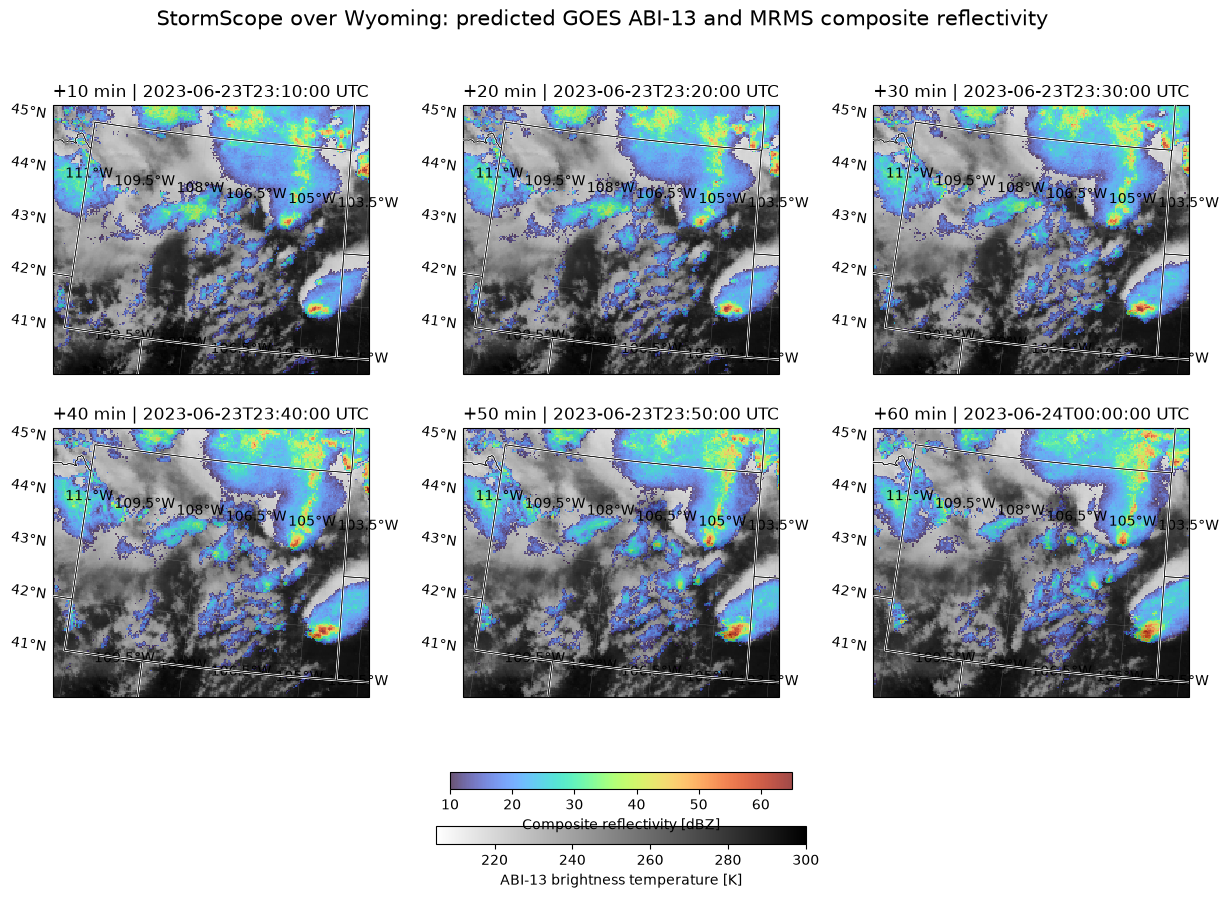

In [11]:
ncols = 3
nrows = int(np.ceil(N_STEPS / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(15, 4.8 * nrows),
    subplot_kw={"projection": HRRR_CRS},
    squeeze=False,
)

last_ir = None
last_refc = None
for idx, ax in enumerate(axes.flat):
    if idx >= N_STEPS:
        ax.set_visible(False)
        continue

    ir = frame_2d(goes_forecasts[idx], goes_ir_index)
    refc = frame_2d(mrms_forecasts[idx], refc_index)
    ir = np.where(goes_valid, ir, np.nan)
    refc = np.where(mrms_valid & (refc >= 10.0), refc, np.nan)

    last_ir = ax.pcolormesh(
        lon_grid, lat_grid, ir,
        transform=ccrs.PlateCarree(), cmap="gray_r", shading="auto",
        vmin=205, vmax=300,
    )
    last_refc = ax.pcolormesh(
        lon_grid, lat_grid, refc,
        transform=ccrs.PlateCarree(), cmap="turbo", shading="auto",
        vmin=10, vmax=65, alpha=0.72,
    )
    decorate_map(ax)
    minutes = lead_minutes(forecast_coords[idx])
    valid_time = INIT_TIME + np.timedelta64(minutes, "m")
    ax.set_title(f"+{minutes:02d} min | {valid_time} UTC")

fig.suptitle(
    "StormScope over Wyoming: predicted GOES ABI-13 and MRMS composite reflectivity",
    fontsize=15,
)
fig.colorbar(last_ir, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.05,
             fraction=0.025, label="ABI-13 brightness temperature [K]")
fig.colorbar(last_refc, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.11,
             fraction=0.025, label="Composite reflectivity [dBZ]")
plt.show()

## 12. Plot predicted lightning density

`glm_density` is a gridded GLM lightning field carried as part of the MRMS model state in the updated workflow. It is useful as a convective-intensity and electrification signal, but it is not a direct count of cloud-to-ground strikes at a point.

A logarithmic color normalization is often useful because lightning density is strongly skewed. The cell below uses `log1p` only for display; it does not alter the model output.

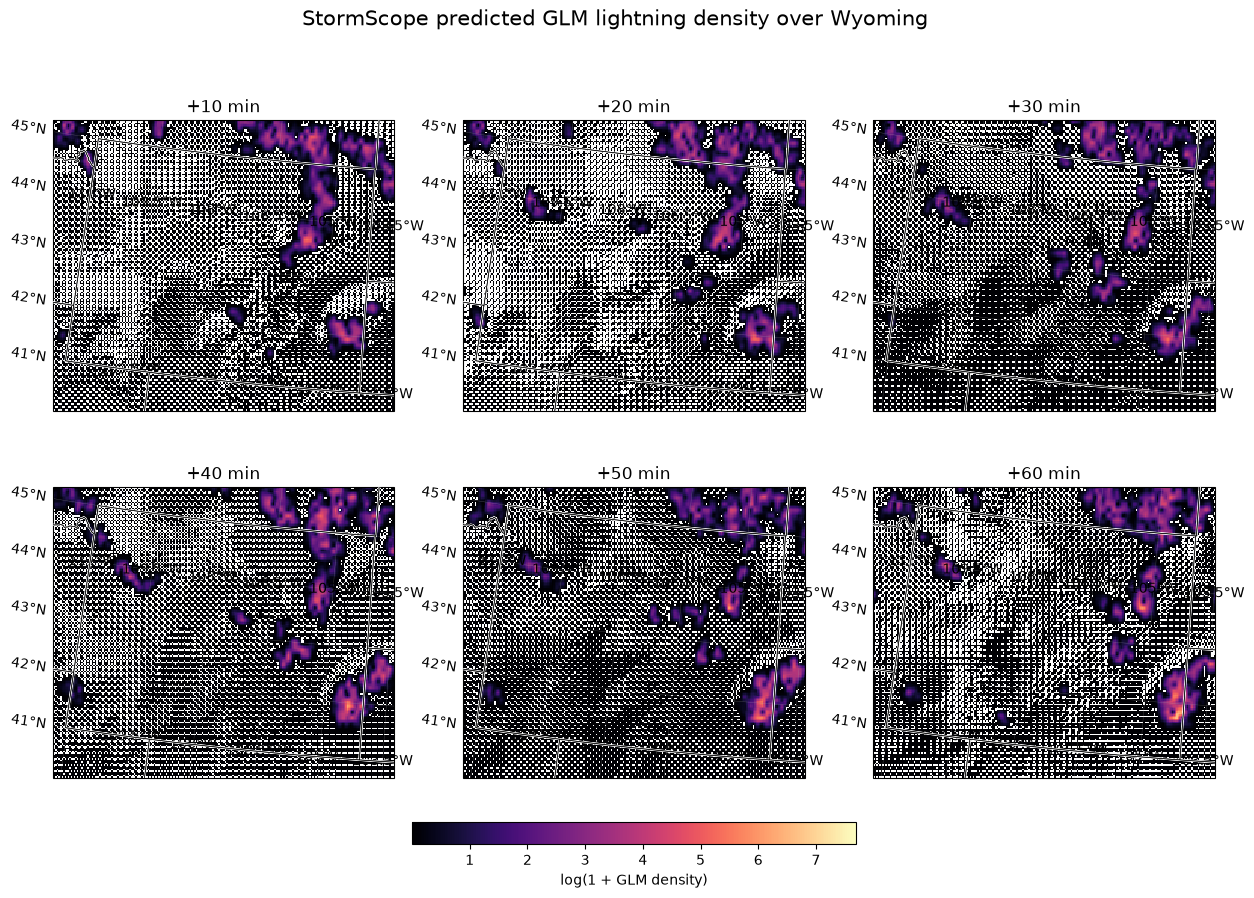

In [12]:
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(15, 4.8 * nrows),
    subplot_kw={"projection": HRRR_CRS},
    squeeze=False,
)

last_glm = None
for idx, ax in enumerate(axes.flat):
    if idx >= N_STEPS:
        ax.set_visible(False)
        continue
    glm = frame_2d(mrms_forecasts[idx], glm_index)
    glm = np.where(mrms_valid & (glm > 0), np.log1p(glm), np.nan)
    last_glm = ax.pcolormesh(
        lon_grid, lat_grid, glm,
        transform=ccrs.PlateCarree(), cmap="magma", shading="auto",
    )
    decorate_map(ax)
    minutes = lead_minutes(mrms_forecast_coords[idx])
    ax.set_title(f"+{minutes:02d} min")

fig.suptitle("StormScope predicted GLM lightning density over Wyoming", fontsize=15)
fig.colorbar(last_glm, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.06,
             fraction=0.03, label="log(1 + GLM density)")
plt.show()

## 13. Wyoming summary diagnostics

These are descriptive diagnostics, not calibrated warning thresholds:

- maximum composite reflectivity in the selected domain;
- fraction of valid model-grid cells at or above 20, 30, 40, and 50 dBZ;
- maximum predicted GLM density.

Because StormScope uses an approximately uniform 3-km projected grid, grid-cell fractions are reasonable quick area proxies. For publication-quality area statistics, use projected cell areas explicitly.

In [13]:
rows = []
for idx in range(N_STEPS):
    refc = frame_2d(mrms_forecasts[idx], refc_index)
    glm = frame_2d(mrms_forecasts[idx], glm_index)
    minutes = lead_minutes(mrms_forecast_coords[idx])
    values = refc[wyoming_mask]
    glm_values = glm[wyoming_mask]
    row = {
        "lead_min": minutes,
        "valid_time_utc": str(INIT_TIME + np.timedelta64(minutes, "m")),
        "max_refc_dbz": float(np.nanmax(values)),
        "max_glm_density": float(np.nanmax(glm_values)),
    }
    for threshold in (20, 30, 40, 50):
        row[f"area_ge_{threshold}dbz_pct"] = 100.0 * float(np.nanmean(values >= threshold))
    rows.append(row)

summary = pd.DataFrame(rows).round(3)
summary

,lead_min,valid_time_utc,max_refc_dbz,max_glm_density,area_ge_20dbz_pct,area_ge_30dbz_pct,area_ge_40dbz_pct,area_ge_50dbz_pct
0,10,2023-06-23T23:10:00,67.510,223.190,14.775,3.475,0.793,0.204
1,20,2023-06-23T23:20:00,70.223,240.190,15.037,3.305,0.882,0.226
2,30,2023-06-23T23:30:00,77.568,330.125,14.998,3.341,0.994,0.274
3,40,2023-06-23T23:40:00,72.097,498.943,15.037,3.285,1.136,0.307
4,50,2023-06-23T23:50:00,66.015,489.860,15.255,3.425,1.069,0.293
5,60,2023-06-24T00:00:00,65.083,757.363,15.291,3.573,1.097,0.307


## 14. Optional ensemble probability map

If `BATCH_SIZE > 1`, each batch member is a plausible diffusion sample. An exceedance probability such as

\[
P(\mathrm{refc} \ge 40\,\mathrm{dBZ})
\]

is estimated by the fraction of members exceeding the threshold at each grid cell. A tiny ensemble is useful for demonstration but is not a stable operational probability estimate.

In [14]:
if BATCH_SIZE > 1:
    threshold = 40.0
    last = mrms_forecasts[-1][:, 0, 0, refc_index].numpy()
    probability = np.mean(last >= threshold, axis=0)
    probability = np.where(mrms_valid, probability, np.nan)

    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=HRRR_CRS)
    im = ax.pcolormesh(
        lon_grid, lat_grid, probability,
        transform=ccrs.PlateCarree(), cmap="viridis", shading="auto",
        vmin=0, vmax=1,
    )
    decorate_map(ax)
    minutes = lead_minutes(mrms_forecast_coords[-1])
    ax.set_title(f"StormScope P(refc ≥ {threshold:.0f} dBZ), +{minutes} min")
    plt.colorbar(im, ax=ax, label="Ensemble exceedance probability")
    plt.show()
else:
    print("Set BATCH_SIZE > 1 and rerun from the batching cell to make a probability map.")

Set BATCH_SIZE > 1 and rerun from the batching cell to make a probability map.


## 15. Optional verification against later MRMS observations

The cleanest first verification is to fetch MRMS at each forecast valid time, regrid it with the same already-built MRMS interpolator, and compare it with predicted `refc`.

This cell reports:

- mean absolute error (MAE);
- root-mean-square error (RMSE);
- critical success index (CSI) at 30 dBZ.

For a generative model, one-member RMSE is incomplete. A serious evaluation should use an ensemble and proper probabilistic scores, multiple cases, a held-out period, and baselines such as persistence or advection. Also note that this 2023 demonstration case lies within the model card's stated 2018–2023 training period, so it is **not** an independent skill evaluation.

In [15]:
RUN_VERIFICATION = False

if RUN_VERIFICATION:
    lead_values = np.asarray([lead_minutes(c) for c in mrms_forecast_coords])
    valid_times = np.asarray([INIT_TIME + np.timedelta64(int(m), "m") for m in lead_values])

    truth, truth_coords = fetch_data(
        mrms_source,
        time=valid_times,
        variable=np.asarray(["refc"]),
        lead_time=np.asarray([np.timedelta64(0, "m")]),
        device=DEVICE,
    )
    truth = mrms_model.input_interp(truth).detach().cpu().numpy()[:, 0, 0]
    prediction = np.stack([
        frame_2d(frame, refc_index, member=0) for frame in mrms_forecasts
    ])

    verification_rows = []
    threshold = 30.0
    for idx, minutes in enumerate(lead_values):
        mask = wyoming_mask & np.isfinite(truth[idx]) & np.isfinite(prediction[idx])
        obs = truth[idx][mask]
        pred = prediction[idx][mask]
        mae = np.mean(np.abs(pred - obs))
        rmse = np.sqrt(np.mean((pred - obs) ** 2))

        obs_event = obs >= threshold
        pred_event = pred >= threshold
        hits = np.sum(obs_event & pred_event)
        misses = np.sum(obs_event & ~pred_event)
        false_alarms = np.sum(~obs_event & pred_event)
        csi_denominator = hits + misses + false_alarms
        csi = hits / csi_denominator if csi_denominator else np.nan

        verification_rows.append({
            "lead_min": int(minutes),
            "mae_dbz": mae,
            "rmse_dbz": rmse,
            "csi_30dbz": csi,
            "valid_cells": int(mask.sum()),
        })

    verification = pd.DataFrame(verification_rows).round(3)
    display(verification)
else:
    print("Set RUN_VERIFICATION=True to fetch verifying MRMS observations.")

Set RUN_VERIFICATION=True to fetch verifying MRMS observations.


## 16. Save the Wyoming subset to Zarr

This cell writes a compact, analysis-ready dataset with:

- all forecast steps;
- all batch members;
- ABI-13 brightness temperature;
- composite and base reflectivity;
- GLM density;
- 2-D latitude/longitude coordinates;
- a valid-grid mask and experiment metadata.

Only the smallest rectangular y/x window enclosing Wyoming is stored. Grid cells in that rectangle but outside the state bounding box remain present; use `valid_domain` plus a precise state polygon later if exact administrative clipping is required.

In [16]:
iy, ix = np.where(geographic_mask(WYOMING_EXTENT))
y_slice = slice(iy.min(), iy.max() + 1)
x_slice = slice(ix.min(), ix.max() + 1)

lead_values = np.asarray([lead_minutes(c) for c in mrms_forecast_coords])

goes_stack = np.stack([
    frame[:, 0, 0, goes_ir_index].numpy()[:, y_slice, x_slice]
    for frame in goes_forecasts
], axis=1)  # [member, forecast_step, y, x]

refc_stack = np.stack([
    frame[:, 0, 0, refc_index].numpy()[:, y_slice, x_slice]
    for frame in mrms_forecasts
], axis=1)
refc_base_stack = np.stack([
    frame[:, 0, 0, refc_base_index].numpy()[:, y_slice, x_slice]
    for frame in mrms_forecasts
], axis=1)
glm_stack = np.stack([
    frame[:, 0, 0, glm_index].numpy()[:, y_slice, x_slice]
    for frame in mrms_forecasts
], axis=1)

dataset = xr.Dataset(
    data_vars={
        "abi13c": (("member", "forecast_step", "y", "x"), goes_stack),
        "refc": (("member", "forecast_step", "y", "x"), refc_stack),
        "refc_base": (("member", "forecast_step", "y", "x"), refc_base_stack),
        "glm_density": (("member", "forecast_step", "y", "x"), glm_stack),
        "valid_domain": (("y", "x"), mrms_valid[y_slice, x_slice]),
    },
    coords={
        "member": np.arange(BATCH_SIZE),
        "forecast_step": np.arange(1, N_STEPS + 1),
        "lead_minutes": ("forecast_step", lead_values),
        "valid_time": ("forecast_step", INIT_TIME + lead_values.astype("timedelta64[m]")),
        "latitude": (("y", "x"), lat_grid[y_slice, x_slice]),
        "longitude": (("y", "x"), lon_grid[y_slice, x_slice]),
    },
    attrs={
        "title": "StormScope coupled nowcast over Wyoming",
        "initialization_time_utc": str(INIT_TIME),
        "model_name": MODEL_NAME,
        "goes_satellite": GOES_SATELLITE,
        "earth2studio_version": metadata.version("earth2studio"),
        "seed": SEED,
        "note": "Research/education output; not for operational warning decisions.",
    },
)

dataset["abi13c"].attrs.update(long_name="GOES ABI channel 13 brightness temperature", units="K")
dataset["refc"].attrs.update(long_name="MRMS composite reflectivity", units="dBZ")
dataset["refc_base"].attrs.update(long_name="MRMS base reflectivity", units="dBZ")

output_store = OUTPUT_DIR / "stormscope_wyoming_20230623.zarr"
dataset.to_zarr(output_store, mode="w")
print("Saved:", output_store.resolve())
dataset

Saved: /lustre/fs1/portfolios/coreai/projects/coreai_modulus_cae/users/nsobhani/forks/wyoming-ai-forecast/outputs/stormscope_wyoming_20230623.zarr


<xarray.Dataset> Size: 5MB
Dimensions:        (member: 1, forecast_step: 6, y: 192, x: 227)
Coordinates:
  * member         (member) int64 8B 0
  * forecast_step  (forecast_step) int64 48B 1 2 3 4 5 6
    lead_minutes   (forecast_step) int64 48B 10 20 30 40 50 60
    valid_time     (forecast_step) datetime64[s] 48B 2023-06-23T23:10:00 ... ...
    latitude       (y, x) float32 174kB 40.1 40.1 40.1 ... 45.86 45.86 45.86
    longitude      (y, x) float32 174kB 248.8 248.9 248.9 ... 256.3 256.3 256.3
Dimensions without coordinates: y, x
Data variables:
    abi13c         (member, forecast_step, y, x) float32 1MB 286.0 ... 217.9
    refc           (member, forecast_step, y, x) float32 1MB -10.01 ... 34.46
    refc_base      (member, forecast_step, y, x) float32 1MB -10.03 ... 30.69
    glm_density    (member, forecast_step, y, x) float32 1MB 0.0 ... 0.0005908
    valid_domain   (y, x) bool 44kB True True True True ... True True True True
Attributes:
    title:                    StormScope coupled nowcast over Wyoming
    initialization_time_utc:  2023-06-23T23:00:00
    model_name:               3km_10min
    goes_satellite:           goes16
    earth2studio_version:     0.15.0rc0
    seed:                     42
    note:                     Research/education output; not for operational ...

## 17. How to interpret this case

For the Chugwater–Hawk Springs event, look for consistency across fields rather than treating any single pixel as a decision product:

1. **ABI-13 evolution:** Are cold cloud tops expanding, cooling, or becoming more structured?
2. **Reflectivity evolution:** Does a coherent high-dBZ core persist or intensify? Is its motion plausible from one frame to the next?
3. **Lightning evolution:** Does predicted electrification increase near the same convective core?
4. **Member agreement:** If using an ensemble, do members agree on location and intensity, or only on a broad threat region?
5. **Verification:** Does the model outperform persistence/advection for this lead time?

What you cannot infer from this notebook alone:

- tornado occurrence or rotation (no Doppler velocity is predicted here);
- hail size or surface wind gusts;
- warning polygons or calibrated impact probabilities;
- whether a single visually compelling member is likely.

Wyoming adds a specific scientific caution: complex terrain and radar geometry can create coverage/quality limitations. MRMS is a merged product, but beam blockage, overshooting, and distance from radars still matter. Treat suspiciously smooth gaps or discontinuities as possible observing-system artifacts before interpreting them as atmospheric signals.

## 18. Troubleshooting

### Import errors for `GOESGLMGrid`, `3km_10min`, or GLM variables

Your Earth2Studio build is older than the current example. Update from the repository version shown in the installation cell, restart the kernel, and rerun from the top.

### `NotImplementedError` or checkpoint/package problems

Use `StormScopeBase.load_default_package()` exactly as shown, then pass that package to both model classes. Do not call an unrelated model's package loader. Confirm that Hugging Face is reachable and that you accept the NVIDIA Open Model License governing the checkpoint.

### Missing GOES files

Check all three of: satellite platform, scan mode, and time. This notebook's 2023 case uses `goes16` and CONUS scan mode `C`. For a post-2025 event, use the current GOES-East platform supported by your Earth2Studio version. Initialization and history times must align with source availability.

### Missing MRMS or GLM data

Keep the initialization on a 10-minute boundary. Public archives occasionally contain gaps. Try a neighboring 10-minute cycle and inspect the fetched time coordinates. Do not silently fill a long missing history with zeros.

### CUDA out of memory

Use `BATCH_SIZE=1`, `USE_COMPILE=False`, close other GPU processes, restart the kernel, and rerun. Cropping `PLOT_EXTENT` does not lower model memory because inference remains full-CONUS. Do not switch to `6km_1hr` by changing only the name: the legacy hourly workflow has a different conditioning contract and should be implemented from its matching official example/configuration.

### `torch.compile` fails or takes too long

Leave `USE_COMPILE=False`. Compilation is an optimization, not a scientific requirement.

### Cartopy boundary download errors

Cartopy may download Natural Earth boundaries on first use. If the classroom network blocks that download, pre-stage Cartopy's data directory or temporarily omit `cfeature` layers; the forecast itself is unaffected.

### The map looks blank

Print field minima/maxima before plotting, confirm that `PLOT_EXTENT` intersects the grid, and lower the reflectivity display cutoff from 10 dBZ. A blank reflectivity overlay may simply mean little echo in that member/lead.

### Results change after rerunning

StormScope is generative. Keep the seed fixed for repeatability, but use multiple members—not a handpicked seed—for uncertainty analysis.

## 19. Suggested exercises

1. Change `PLOT_EXTENT` to `EVENT_EXTENT` and trace the Chugwater-to-Hawk Springs corridor.
2. Increase `N_STEPS` from 6 to 12 and identify when forecast structure begins to lose plausibility.
3. Run `BATCH_SIZE=4`; plot the probability of `refc ≥ 40 dBZ` and compare it with any one member.
4. Enable verification and add persistence as a baseline: use the last observed MRMS frame for every lead.
5. Replace bounding-box statistics with an exact Wyoming state polygon.
6. Repeat with a 2024 or 2025 held-out case for a more defensible evaluation.
7. Compute neighborhood fractions skill score instead of pointwise CSI to account for spatial displacement.
8. Save all eight ABI channels and create a multi-spectral diagnostic view.

### Reproducibility checklist

Record the Earth2Studio version/commit, checkpoint package version, data timestamps actually returned, GPU type, PyTorch/CUDA versions, seed, batch size, AMP/compile settings, map extent, and any missing-data handling. These details are part of the experiment—not incidental setup.